<a href="https://colab.research.google.com/github/nirmalpate/Langgraph-Chatbot-With-Tools/blob/main/Langgraph_Chatbot_With_Tools.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [42]:
!pip install langgraph langsmith langchain langchain_groq langchain_community

In [43]:
from typing import Annotated
from typing_extensions import TypedDict

In [44]:
!pip install arxiv wikipedia

In [45]:
## Working With Tools

from langchain_community.utilities import ArxivAPIWrapper,WikipediaAPIWrapper
from langchain_community.tools import ArxivQueryRun,WikipediaQueryRun

## Arxiv And Wikipedia tools

arxiv_wrapper=ArxivAPIWrapper(top_k_results=1,doc_content_chars_max=2000)
arxiv_tool=ArxivQueryRun(api_wrapper=arxiv_wrapper)

api_wrapper=WikipediaAPIWrapper(top_k_results=1,doc_content_chars_max=2000)
wiki_tool=WikipediaQueryRun(api_wrapper=api_wrapper)

In [46]:
try:
    result = wiki_tool.invoke("who is Peter Thiel")
    print(result)
except Exception as e:
    print(f"An error occurred while invoking the Wikipedia tool: {e}")
    print("This often happens if there's a problem with the Wikipedia API response (e.g., not returning valid JSON) or network connectivity.")
    print("Please check your internet connection or try again later.")

Page: Peter Thiel
Summary: Peter Andreas Thiel ( ; born 11 October 1967) is a German-American entrepreneur, venture capitalist, and conservative political activist. A co-founder of PayPal, Palantir Technologies, and Founders Fund, he was also the first outside investor in Facebook. As of August 2026, Forbes estimated Thiel's net worth at US$32 billion.
Born in Germany, Thiel moved to the US with his parents when he was an infant. In 1971, his family moved to South African-occupied Namibia, before moving back to the US in 1977. After graduating from Stanford University, Thiel worked as a clerk, a securities lawyer, a speechwriter, and a derivatives trader at Credit Suisse. He founded Thiel Capital Management in 1996 and co-founded PayPal with Max Levchin and Luke Nosek in 1998. He was PayPal's chief executive officer until its sale to eBay in 2002 for $1.5 billion.
Thiel then founded Clarium Capital, a global macro hedge fund based in San Francisco. He launched Palantir in 2003, a big d

In [47]:
import arxiv

try:
    client = arxiv.Client()
    search = arxiv.Search(
        query="Attention is all you need",
        max_results=1,
        sort_by=arxiv.SortCriterion.Relevance,
        sort_order=arxiv.SortOrder.Descending
    )
    result_list = list(client.results(search))
    if result_list:
        entry = result_list[0]
        # Extract desired information, similar to what ArxivAPIWrapper would do
        output = f"Title: {entry.title}\nAuthors: {', '.join([a.name for a in entry.authors])}\nSummary: {entry.summary}\nURL: {entry.pdf_url}"
        # Truncate summary if needed, similar to doc_content_chars_max
        if len(output) > 2000: # Using the doc_content_chars_max from arxiv_wrapper as a guideline
            output = output[:1997] + "..."
        print(output)
    else:
        print("No results found for 'Attention is all you need'.")
except AttributeError as e:
    print(f"An AttributeError occurred: {e}")
    print("This indicates an incompatibility with the arxiv library version. The 'Search' object no longer has a 'results' attribute or method.")
    print("You might need to downgrade the 'arxiv' library (e.g., !pip install arxiv==1.4.0) or update the usage to match the current arxiv library API.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

Title: Do You Even Need Attention? A Stack of Feed-Forward Layers Does Surprisingly Well on ImageNet
Authors: Luke Melas-Kyriazi
Summary: The strong performance of vision transformers on image classification and other vision tasks is often attributed to the design of their multi-head attention layers. However, the extent to which attention is responsible for this strong performance remains unclear. In this short report, we ask: is the attention layer even necessary? Specifically, we replace the attention layer in a vision transformer with a feed-forward layer applied over the patch dimension. The resulting architecture is simply a series of feed-forward layers applied over the patch and feature dimensions in an alternating fashion. In experiments on ImageNet, this architecture performs surprisingly well: a ViT/DeiT-base-sized model obtains 74.9\% top-1 accuracy, compared to 77.9\% and 79.9\% for ViT and DeiT respectively. These results indicate that aspects of vision transformers other

In [48]:
tools=[wiki_tool,arxiv_tool]

In [49]:
## Langgraph Application

from langgraph.graph.message import add_messages
class State(TypedDict):
  messages:Annotated[list,add_messages]


In [50]:
from langgraph.graph import StateGraph,START,END
graph_builder= StateGraph(State)
from langchain_groq import ChatGroq

In [51]:
from google.colab import userdata
groq_api_key=userdata.get("groq1api1key")

In [52]:
llm=ChatGroq(groq_api_key=groq_api_key,model_name="openai/gpt-oss-20b")
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.6.1', 'langchain': '1.3.18'}}, profile={'name': 'GPT OSS 20B', 'release_date': '2025-08-05', 'last_updated': '2026-05-27', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x7d13f24b9e00>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x7d13f24ba780>, model_name='openai/gpt-oss-20b', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [53]:
llm_with_tools = llm.bind_tools(tools = tools)

In [54]:
def chatbot(state:State):
  return {"messages":[llm_with_tools.invoke(state["messages"])]}

In [55]:
from langgraph.prebuilt import ToolNode,tools_condition
graph_builder.add_node("chatbot",chatbot)
tool_node = ToolNode(tools=tools)
graph_builder.add_node("tools", tool_node)

graph_builder.add_conditional_edges(
    "chatbot",
    tools_condition,
)

graph_builder.add_edge("tools", "chatbot")
graph_builder.add_edge(START,"chatbot")

In [56]:
graph=graph_builder.compile()

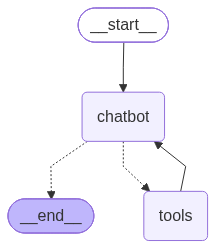

In [57]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

In [58]:
user_input="Hi there!, My name is John"

events=graph.stream(
     {"messages": [("user", user_input)]},stream_mode="values"
)

for event in events:
  event["messages"][-1].pretty_print()

================================ Human Message =================================

Hi there!, My name is John
================================== Ai Message ==================================

Hi John! 👋 How can I help you today?


In [60]:
user_input = "what is Oktoberfest."

# The config is the **second positional argument** to stream() or invoke()!
events = graph.stream(
    {"messages": [("user", user_input)]},stream_mode="values"
)
for event in events:
    event["messages"][-1].pretty_print()

================================ Human Message =================================

what is Oktoberfest.
================================== Ai Message ==================================

**Oktoberfest** is the world’s largest and most famous beer festival, held annually in Munich, Germany. It’s a celebration of Bavarian culture, hospitality, and, of course, beer.

| Aspect | Details |
|--------|---------|
| **When?** | Traditionally starts in late September and runs for 16–18 days, ending on the first Sunday in October. The name “Oktoberfest” comes from its original founding date in 1810, which was in October. |
| **Where?** | The Theresienwiese (“Theresa’s Field”) in Munich’s city center. The site covers about 200 acres (≈ 80 hectares) and can accommodate over 600,000 visitors per day. |
| **Origins** | • **1810** – The first Oktoberfest was a wedding celebration for Crown Prince Ludwig (later King Ludwig I) and Princess Therese of Saxe-Hildburghausen. <br>• It was a public celebration 